## **Notebook 4 - Deep Learning using LSTM**

In this notebook, we implement a Deep Learning model (LSTM) using the preprocessed dataset.

#### Objectives:
- Use prepared train and test datasets
- Convert text into sequences
- Train an LSTM model
- Evaluate performance and compare with ML models

This notebook focuses only on Deep Learning without repeating preprocessing steps.

#### **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt

import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score


#### **Logger Configuration**

This project uses Python logging instead of print statements.

Why?
- Debugging large datasets
- Tracking preprocessing steps
- Production ML pipelines
- Helps identify where a failure occurred

All activities will be recorded inside:
`deep_learning_lstm.log`

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "deep_learning_lstm.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8")
    ],
    force=True
)

logger = logging.getLogger(__name__)

logger.info("==== DEEP LEARNING LSTM PIPELINE STARTED ====")
print(f"Logging to: {LOG_FILE}")

Logging to: E:\DData\Projects\DSC\NextHikes\Python\disaster-tweet-classification-nlp-pro-7\logs\deep_learning_lstm.log


#### **Load Dataset**

In [3]:
logger.info("Loading dataset for deep learning LSTM...")
train_df = pd.read_csv("../data/train_dataset_prepared.csv")
test_df = pd.read_csv("../data/test_dataset_prepared.csv")
logger.info("Dataset for deep learning LSTM loaded successfully.")
train_df.head()

,text,clean_text,target
0,Sassy city girl country hunk stranded in Smoky...,sassy city girl country hunk stranded in smoky...,1
1,God's Kingdom (Heavenly Gov't) will rule over ...,gods kingdom heavenly govt will rule over all ...,0
2,Mopheme and Bigstar Johnson are a problem in t...,mopheme and bigstar johnson are a problem in t...,0
3,@VixMeldrew sounds like a whirlwind life!,sounds like a whirlwind life,0
4,Malaysia confirms plane debris washed up on Re...,malaysia confirms plane debris washed up on re...,1


---

#### **Define Features and Target**

In [4]:
logger.info("Preparing data for deep learning LSTM...")
X_train = train_df["clean_text"]
y_train = train_df["target"]

X_test = test_df["clean_text"]
y_test = test_df["target"]
logger.info("Data for deep learning LSTM prepared successfully.")

---
#### **Tokenization**

Convert text into sequences for LSTM input.

In [5]:
logger.info("Tokenizing and padding sequences for deep learning LSTM...")
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
logger.info(
    f"Tokenization completed successfully. "
    f"train_sequences={len(X_train_seq)}, "
    f"test_sequences={len(X_test_seq)}, "
    f"first_train_seq_len={len(X_train_seq[0]) if X_train_seq else 0}, "
    f"first_test_seq_len={len(X_test_seq[0]) if X_test_seq else 0}"
)
print(
    f"Tokenization completed successfully. "
    f"train_sequences={len(X_train_seq)}, "
    f"test_sequences={len(X_test_seq)}, "
    f"first_train_seq_len={len(X_train_seq[0]) if X_train_seq else 0}, "
    f"first_test_seq_len={len(X_test_seq[0]) if X_test_seq else 0}"
)

Tokenization completed successfully. train_sequences=6090, test_sequences=1523, first_train_seq_len=13, first_test_seq_len=10


---
#### **Padding Sequences**
To ensure all input sequences have a uniform length for the LSTM model, the tokenized training and test sequences were padded to `max_len = 100` using post-padding. This step converted variable-length token lists into fixed-size arrays suitable for deep learning.

- `X_train_pad.shape`: shape of the padded training data
- `X_test_pad.shape`: shape of the padded test data

The logger records successful completion of padding along with the resulting dataset shapes for traceability.


In [6]:
logger.info("Starting padding sequences for deep learning LSTM...")
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")
logger.info(f"Padding completed successfully. X_train_pad_shape={X_train_pad.shape}, X_test_pad_shape={X_test_pad.shape}")
print(f"Padding completed successfully. X_train_pad_shape={X_train_pad.shape}, X_test_pad_shape={X_test_pad.shape}")
X_train_pad
X_test_pad

Padding completed successfully. X_train_pad_shape=(6090, 100), X_test_pad_shape=(1523, 100)


array([[6836,   61,   48, ...,    0,    0,    0],
       [2323, 1567,  109, ...,    0,    0,    0],
       [  64,    1,    1, ...,    0,    0,    0],
       ...,
       [ 626,   15, 1902, ...,    0,    0,    0],
       [ 147,    7,   69, ...,    0,    0,    0],
       [ 512, 1247,    1, ...,    0,    0,    0]],
      shape=(1523, 100), dtype=int32)

---

#### **Building the LSTM Model**

An LSTM-based deep learning model was constructed for binary tweet classification. The architecture begins with an `Embedding` layer to convert token indices into dense vector representations, followed by an `LSTM` layer with 64 units to capture sequential dependencies in the text.

A `Dropout` layer with a rate of 0.5 was added to reduce overfitting, followed by a dense hidden layer with 32 ReLU units and a final sigmoid output layer for binary classification.

**Model configuration:**
- Vocabulary size: `10,000`
- Maximum sequence length: `100`
- Embedding dimension: `128`
- LSTM units: `64`
- Dropout rate: `0.5`
- Dense hidden units: `32`
- Output units: `1`


In [7]:
logger.info("Building improved Bidirectional LSTM model...")

# Key improvements over the original architecture:
# 1. Bidirectional LSTM — reads the tweet forwards AND backwards,
#    helping it understand that "weather is beautiful" (safe) vs
#    "severe weather warning" (disaster) differ by surrounding context.
# 2. SpatialDropout1D — drops entire word embedding dimensions rather
#    than random values, which is more effective for NLP tasks.
# 3. Larger embedding (128-dim) and LSTM (128 units) for richer representations.

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    SpatialDropout1D(0.3),             # drops embedding channels, better for NLP
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

logger.info(
    f"Bidirectional LSTM model built. vocab_size={vocab_size}, "
    f"max_len={max_len}, embedding_dim=128, lstm_units=128+64, "
    f"bidirectional=True, spatial_dropout=0.3"
)
print(
    f"Bidirectional LSTM model built. vocab_size={vocab_size}, "
    f"max_len={max_len}, embedding_dim=128"
)
model.summary()


Bidirectional LSTM model built. vocab_size=10000, max_len=100, embedding_dim=128


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---

#### **Compiling the LSTM Model**

The LSTM model is compiled for a binary classification task using `binary_crossentropy` as the loss function, `adam` as the optimizer, and `accuracy` as the evaluation metric. The sigmoid activation in the output layer makes the model suitable for predicting the probability of a tweet belonging to the disaster class.

**Compilation configuration:**
- Loss function: `binary_crossentropy`
- Optimizer: `adam`
- Evaluation metric: `accuracy`
- Output activation: `sigmoid`
- Task type: `binary classification`


In [8]:
logger.info("Starting compilation of LSTM model for deep learning...")
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
logger.info("LSTM model compiled successfully. loss=binary_crossentropy, optimizer=adam, metrics=['accuracy'], output_activation=sigmoid, task=binary_classification")

---

#### **Training the LSTM Model**

The compiled LSTM model is trained on the padded training data for `5` epochs with a batch size of `32`. A validation split of `20%` is used to monitor generalization performance during training.

The training log captures the final training and validation metrics, including loss and accuracy, which help assess how well the model learned from the data and how it performed on unseen validation samples.

**Training configuration:**
- Epochs: `5`
- Batch size: `32`
- Validation split: `0.2`

**Logged final metrics:**
- Final training loss
- Final training accuracy
- Final validation loss
- Final validation accuracy


In [9]:
logger.info("Starting training of Bidirectional LSTM model...")

# EarlyStopping monitors val_loss and stops if it stops improving.
# This prevents overfitting without needing to guess the right epoch count.
# restore_best_weights=True keeps the weights from the best epoch.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,              # more epochs — EarlyStopping will stop it when ready
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

logger.info(
    f"Training completed. epochs_run={len(history.history['loss'])}, "
    f"final_train_loss={history.history['loss'][-1]:.4f}, "
    f"final_train_accuracy={history.history['accuracy'][-1]:.4f}, "
    f"final_val_loss={history.history['val_loss'][-1]:.4f}, "
    f"final_val_accuracy={history.history['val_accuracy'][-1]:.4f}"
)


Epoch 1/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.6950 - loss: 0.5748 - val_accuracy: 0.8071 - val_loss: 0.4424
Epoch 2/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.8549 - loss: 0.3500 - val_accuracy: 0.7800 - val_loss: 0.4855
Epoch 3/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9117 - loss: 0.2304 - val_accuracy: 0.7447 - val_loss: 0.5641
Epoch 4/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9470 - loss: 0.1570 - val_accuracy: 0.7791 - val_loss: 0.6152
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


---

#### **Evaluating the LSTM Model**

The trained LSTM model is evaluated on the padded test set. Predicted probabilities were converted into binary class labels using a threshold of `0.5`, and the model's test loss and accuracy were computed. A classification report is also generated to summarize precision, recall, and F1-score.

**Evaluation details:**
- Prediction threshold: `0.5`
- Metrics logged: `test_loss`, `test_accuracy`
- Evaluation samples: size of `X_test_pad`


In [10]:
logger.info("Starting evaluation of LSTM model for deep learning...")
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(classification_report(y_test, y_pred))
logger.info(
    f"LSTM model evaluation completed successfully. "
    f"test_loss={loss:.4f}, "
    f"test_accuracy={accuracy:.4f}, "
    f"evaluation_samples={len(X_test_pad)}"
)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8116 - loss: 0.4407
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       869
           1       0.87      0.66      0.75       654

    accuracy                           0.81      1523
   macro avg       0.83      0.79      0.80      1523
weighted avg       0.82      0.81      0.81      1523



---

#### **Calculating F1-Score**

The F1-score is computed to provide a balanced evaluation of the LSTM model by combining precision and recall into a single metric. This is especially useful for binary classification tasks where class balance and prediction quality both matter.

**Logged metric:**
- F1-score: `lstm_f1`


In [11]:
logger.info("Calculating F1-score for LSTM model...")
lstm_f1 = f1_score(y_test, y_pred)
logger.info(f"LSTM model F1-score calculated successfully. lstm_f1={lstm_f1:.4f}")
print(f"LSTM model F1-score: {lstm_f1:.4f}")

LSTM model F1-score: 0.7515


---

#### **Saving the LSTM Model**

The trained LSTM model is saved to `../models/lstm_model.h5` for future inference, evaluation, or reuse without retraining.

**Save details:**
- File path: `../models/lstm_model.h5`
- Saved artifact: trained LSTM model


In [12]:
logger.info("Saving LSTM model for deep learning...")
model.save("../models/lstm_model.h5")
logger.info("LSTM model saved successfully to ../models/lstm_model.h5")

# Save training history so Notebook 5 can plot the accuracy curve
# without retraining the model
import json as _json
with open("../models/lstm_history.json", "w") as _f:
    _json.dump(history.history, _f)
logger.info("Training history saved to ../models/lstm_history.json")
print("Training history saved to models/lstm_history.json")

Training history saved to models/lstm_history.json


---

#### **Training Performance**

The loss curve is plotted to visualize how training loss and validation loss change across epochs. This helps assess model learning behavior and identify signs of convergence or overfitting.

**Plot details:**
- Training loss: `history.history["loss"]`
- Validation loss: `history.history["val_loss"]`
- Figure size: `12 x 6`
- Plot title: `Loss Curve`


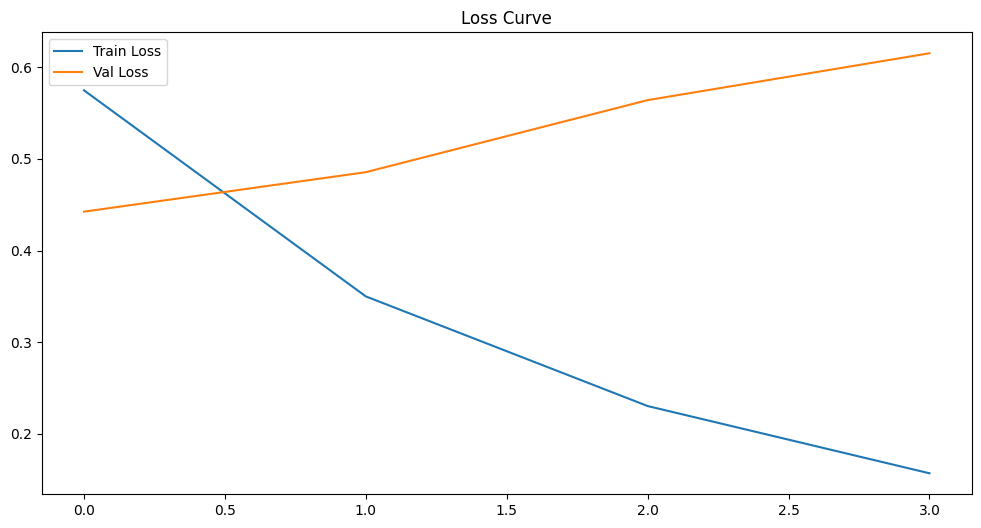

In [13]:
logger.info("Plotting loss curve for LSTM model...")
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.legend()
plt.title("Loss Curve")
plt.show()
logger.info("Loss curve plotted successfully.")
logger.info("==== DEEP LEARNING LSTM PIPELINE COMPLETED ====")

---

### **Summary**

In this notebook, we implemented a Deep Learning model using LSTM on preprocessed data.

#### Key Points:

- Used already prepared train/test datasets (no duplication)
- Converted text into sequences using Tokenizer
- Built and trained an LSTM model
- Evaluated using classification metrics

#### Observations:

- LSTM captures sequential relationships in text
- Performance depends on data size and tuning
- Provides deeper contextual understanding than TF-IDF

#### Conclusion

This notebook complements traditional ML models by introducing a sequence-based Deep Learning approach for text classification.

#### Next Step

Compare ML and LSTM models in final evaluation notebook.